In [1]:
import pickle
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt

# ===============================
# 1. LOAD MODEL + LOAD PKL DATA
# ===============================
model = SentenceTransformer("bkai-foundation-models/vietnamese-bi-encoder")

with open("D:\ARTIFICIAL_INTELLIGENCE\KY_9\AIP491\AIP491_G9\Data\data_train\data_train_v1\data_train_singlequery_v1.pkl", "rb") as f:
     data = pickle.load(f)

print(f"Loaded {len(data)} QA pairs.\n")



C:\Users\Acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loaded 15964 QA pairs.



In [2]:
# 2. TÍNH COSINE + IN TỪNG MẪU
# ===============================
threshold = 0.7
results = []

for idx, item in enumerate(data):
    query, positive = item.texts

    # Encode
    query_emb = model.encode(query)
    pos_emb = model.encode(positive)

    # Score
    score = float(util.cos_sim(query_emb, pos_emb))
    is_pass = score >= threshold

    # Lưu kết quả
    results.append({
        "index": idx,
        "query": query,
        "positive": positive,
        "cosine": score,
        "pass": is_pass
    })

    # === IN RA TỪNG MẪU ===
    print(f"--- Sample {idx+1}/{len(data)} ---")
    # 3. LƯU LẠI CSV ĐỂ DÙNG MODEL KHÁC
# ===============================
df = pd.DataFrame(results)
df.to_csv("qa_scores.csv", index=False, encoding="utf-8-sig")
print("Đã lưu file: qa_scores.csv\n")


--- Sample 1/15964 ---
--- Sample 2/15964 ---
--- Sample 3/15964 ---
--- Sample 4/15964 ---
--- Sample 5/15964 ---
--- Sample 6/15964 ---
--- Sample 7/15964 ---
--- Sample 8/15964 ---
--- Sample 9/15964 ---
--- Sample 10/15964 ---
--- Sample 11/15964 ---
--- Sample 12/15964 ---
--- Sample 13/15964 ---
--- Sample 14/15964 ---
--- Sample 15/15964 ---
--- Sample 16/15964 ---
--- Sample 17/15964 ---
--- Sample 18/15964 ---
--- Sample 19/15964 ---
--- Sample 20/15964 ---
--- Sample 21/15964 ---
--- Sample 22/15964 ---
--- Sample 23/15964 ---
--- Sample 24/15964 ---
--- Sample 25/15964 ---
--- Sample 26/15964 ---
--- Sample 27/15964 ---
--- Sample 28/15964 ---
--- Sample 29/15964 ---
--- Sample 30/15964 ---
--- Sample 31/15964 ---
--- Sample 32/15964 ---
--- Sample 33/15964 ---
--- Sample 34/15964 ---
--- Sample 35/15964 ---
--- Sample 36/15964 ---
--- Sample 37/15964 ---
--- Sample 38/15964 ---
--- Sample 39/15964 ---
--- Sample 40/15964 ---
--- Sample 41/15964 ---
--- Sample 42/15964 ---
-

In [9]:
# 4. THỐNG KÊ
# ===============================

total = len(df)
passed = df["pass"].sum()
failed = total - passed

mean_score = df["cosine"].mean()
min_score = df["cosine"].min()
max_score = df["cosine"].max()

print("========== THỐNG KÊ ==========")
print(f"Tổng số mẫu:         {total}")
print(f"Số mẫu PASS:         {passed}")
print(f"Số mẫu FAIL:         {failed}")
print(f"TỶ LỆ PASS:          {passed/total*100:.2f}%")
print("--------------------------------")
print(f"Cosine TB:           {mean_score:.4f}")
print(f"Cosine thấp nhất:    {min_score:.4f}")
print(f"Cosine cao nhất:     {max_score:.4f}")
print("================================\n")

# Top 10 FAIL thấp nhất
print("===== TOP 10 FAIL THẤP NHẤT =====")
df_fail = df[df["pass"] == False].sort_values(by="cosine")
print(df_fail.head(10)[["index","cosine","query","positive"]])
print("================================\n")

========== THỐNG KÊ ==========
Tổng số mẫu:         15964
Số mẫu PASS:         3158
Số mẫu FAIL:         12806
TỶ LỆ PASS:          19.78%
--------------------------------
Cosine TB:           0.5964
Cosine thấp nhất:    0.0627
Cosine cao nhất:     0.9074

===== TOP 10 FAIL THẤP NHẤT =====
       index    cosine                                              query  \
14526  14526  0.062697  query: Khi đoàn người làm lễ tiến vào từ khu v...   
9765    9765  0.081150  query: Du khách có thể tham gia những hoạt độn...   
14100  14100  0.094419  query: Địa điểm nào được mô tả là hoàn hảo cho...   
12527  12527  0.102843  query: Ở Quảng Ninh, bạn có thể chơi ở những đ...   
7037    7037  0.110771  query: Các tầng trong khu vực được trang trí n...   
8930    8930  0.120494  query: Ở khu vực này có những loại lớp học nào...   
14518  14518  0.122901  query: Những ngôi sao nào được nhắc đến trong ...   
7471    7471  0.130269  query: Giá thành của một bát bún ốc tại đây là...   
6439    6439  0.

===== TOP 10 FAIL THẤP NHẤT =====
       index    cosine                                              query  \
14526  14526  0.062697  query: Khi đoàn người làm lễ tiến vào từ khu v...   
9765    9765  0.081150  query: Du khách có thể tham gia những hoạt độn...   
14100  14100  0.094419  query: Địa điểm nào được mô tả là hoàn hảo cho...   
12527  12527  0.102843  query: Ở Quảng Ninh, bạn có thể chơi ở những đ...   
7037    7037  0.110771  query: Các tầng trong khu vực được trang trí n...   
8930    8930  0.120494  query: Ở khu vực này có những loại lớp học nào...   
14518  14518  0.122901  query: Những ngôi sao nào được nhắc đến trong ...   
7471    7471  0.130269  query: Giá thành của một bát bún ốc tại đây là...   
6439    6439  0.133012  query: Món ăn nào được nhiều người ưa thích, đ...   
5179    5179  0.136775  query: Nơi nào được UNESCO công nhận là Di sản...   

                                                positive  
14526  passage: Đó là lý do vì sao khi đoàn người làm...  


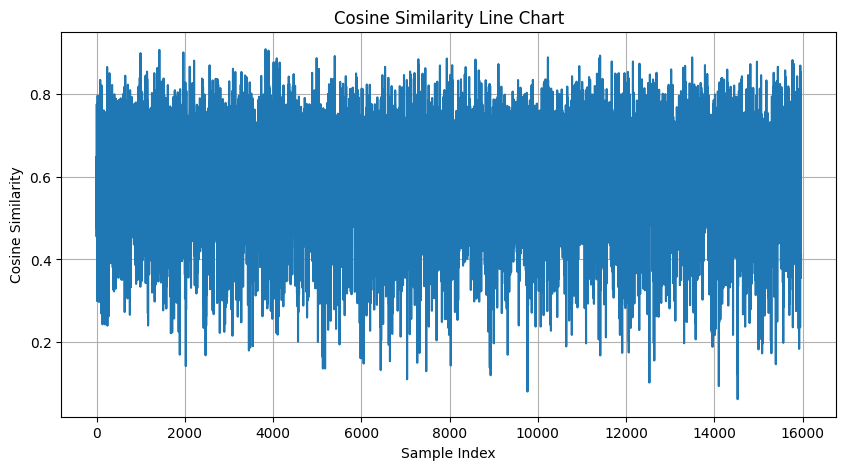

In [10]:
print("===== TOP 10 FAIL THẤP NHẤT =====")
df_fail = df[df["pass"] == False].sort_values(by="cosine")
print(df_fail.head(10)[["index","cosine","query","positive"]])
print("================================\n")

# ===============================
# 5. LINE CHART
# ===============================
plt.figure(figsize=(10,5))
plt.plot(df["cosine"])
plt.title("Cosine Similarity Line Chart")
plt.xlabel("Sample Index")
plt.ylabel("Cosine Similarity")
plt.grid(True)
plt.show()

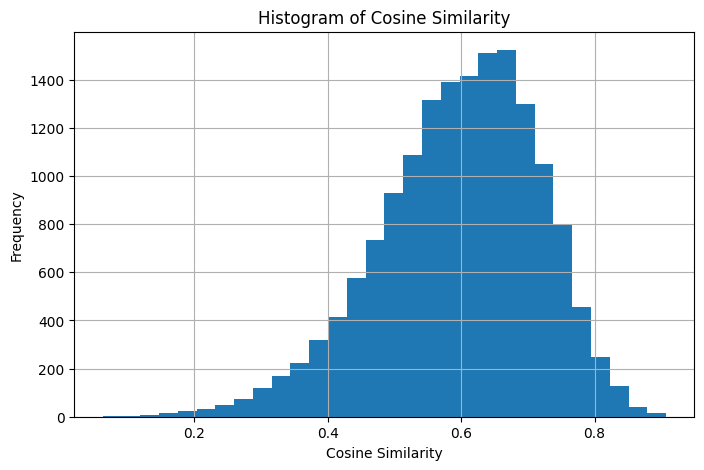

In [12]:
 6. #HISTOGRAM
# ===============================
plt.figure(figsize=(8,5))
plt.hist(df["cosine"], bins=30)
plt.title("Histogram of Cosine Similarity")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()
